# FRTB IMA Risk Monitor — Methodology

A walk-through of the risk methodology behind the [FRTB IMA Risk Monitor](https://github.com/marksguo/frtb-ima-risk-monitor): Historical-Simulation VaR and Expected Shortfall, how the distributional assumption changes the tail, how the model holds up under formal backtests, and how the internal-model capital compares to the Standardised Approach.

Everything is computed live from market data via the project's own `fetch_prices` module, so the notebook is self-contained (no database needed).

In [1]:
%matplotlib inline
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / 'pipeline').exists() and (root.parent / 'pipeline').exists():
    root = root.parent
sys.path.insert(0, str(root))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True, 'grid.alpha': 0.3})
from pipeline.fetch_prices import fetch_prices
from pipeline.config import WEIGHTS, TICKERS, VAR_WINDOW, ALPHA
from pipeline.var_methods import (compare_methods, historical_var_es,
    ewma_volatility, filtered_historical_var_es)
from pipeline.calculate_risk import rolling_var_es, liquidity_adjusted_es
from pipeline.var_backtests import kupiec_pof, christoffersen, breaches_from
from pipeline.standardised_approach import sbm_delta_charge
from pipeline.capital import capital_comparison
print('Imports OK')

Imports OK


## 1. The synthetic trading book

Six liquid ETFs, one per FRTB asset class (equity, rates, credit, EM equity, commodity, FX), held at equal notional weight. Daily portfolio P&L is the equal-weighted mean of the asset returns.

4,812 trading days | 2007-04-12 to 2026-05-27


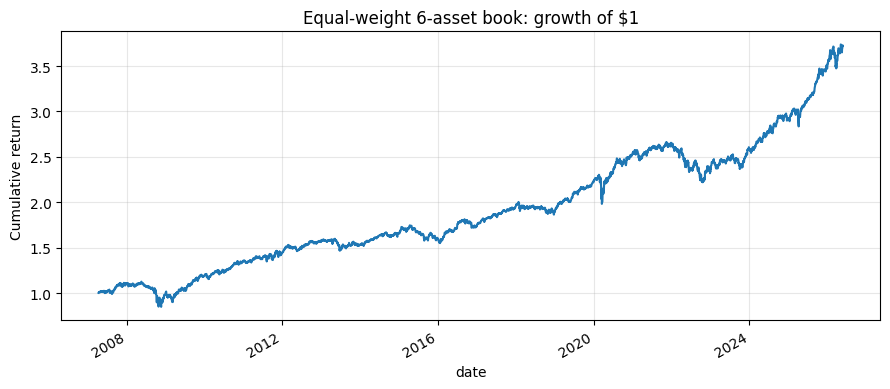

In [2]:
prices = fetch_prices()
wide = prices.pivot(index='date', columns='ticker', values='daily_return')[TICKERS].dropna()
port = (wide * pd.Series(WEIGHTS)).sum(axis=1)
print(f'{len(port):,} trading days | {wide.index.min().date()} to {wide.index.max().date()}')
((1 + port).cumprod()).plot(title='Equal-weight 6-asset book: growth of $1', color='#1f77b4')
plt.ylabel('Cumulative return'); plt.tight_layout(); plt.show()

## 2. Three ways to estimate VaR and Expected Shortfall

- **Historical Simulation** (production method): the empirical 2.5% tail.
- **Parametric (Normal)**: closed-form; thin Gaussian tail understates risk.
- **Monte Carlo (Student-t)**: fits a heavy-tailed t and simulates.

All reported as positive loss magnitudes at 97.5% confidence.

In [3]:
window = port.tail(VAR_WINDOW).to_numpy()
comp = pd.DataFrame(compare_methods(window)).T[['var', 'es']]
comp.columns = ['VaR 97.5%', 'ES 97.5%']
comp.round(4)

,VaR 97.5%,ES 97.5%
Historical,0.0116,0.0156
Parametric (Normal),0.0093,0.0113
Monte Carlo (Student-t),0.0133,0.0303


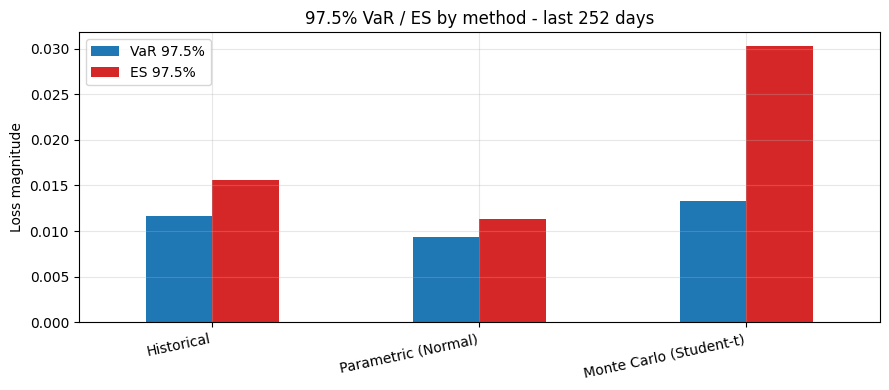

In [4]:
comp.plot(kind='bar', color=['#1f77b4', '#d62728'],
          title=f'97.5% VaR / ES by method - last {VAR_WINDOW} days')
plt.ylabel('Loss magnitude'); plt.xticks(rotation=12, ha='right')
plt.tight_layout(); plt.show()

The Normal model reports the **smallest** ES while the Student-t fit is far larger - the cost of assuming away fat tails, and why FRTB mandates Expected Shortfall and a stressed calibration for capital.

## 3. Reacting to volatility: Filtered Historical Simulation

Plain Historical Simulation weights every day in the window equally, so it reacts slowly when volatility spikes (the source of the backtest failures in section 5). **Filtered Historical Simulation (FHS)** standardises each past return by its EWMA volatility, then rescales to *today's* volatility before taking the tail - so the estimate tracks the current regime.

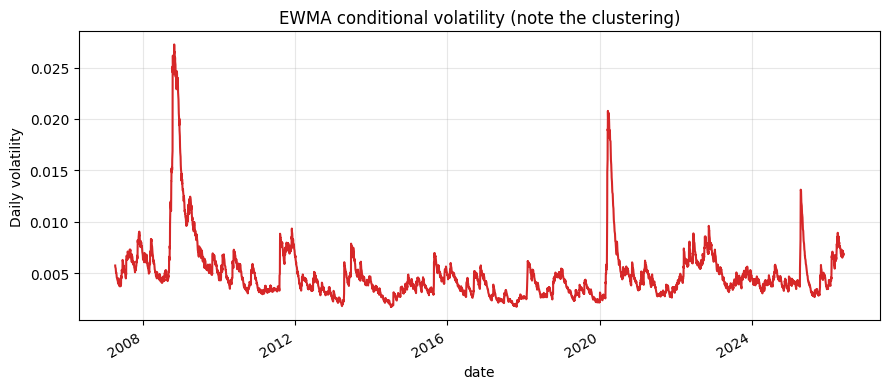

Plain HS    : VaR 0.0116  ES 0.0156
Filtered HS : VaR 0.0148  ES 0.0190
FHS rescales to current volatility, so it leads plain HS when the regime is turbulent.


In [5]:
vol = pd.Series(ewma_volatility(port.to_numpy()), index=port.index)
vol.plot(title='EWMA conditional volatility (note the clustering)', color='#d62728')
plt.ylabel('Daily volatility'); plt.tight_layout(); plt.show()
hv, he = historical_var_es(window)
fv, fe = filtered_historical_var_es(window)
print(f'Plain HS    : VaR {hv:.4f}  ES {he:.4f}')
print(f'Filtered HS : VaR {fv:.4f}  ES {fe:.4f}')
print('FHS rescales to current volatility, so it leads plain HS when the '
      'regime is turbulent.')

## 4. Risk through time

Rolling 252-day VaR and ES. ES sits above VaR by construction and the spread widens in turbulent periods.

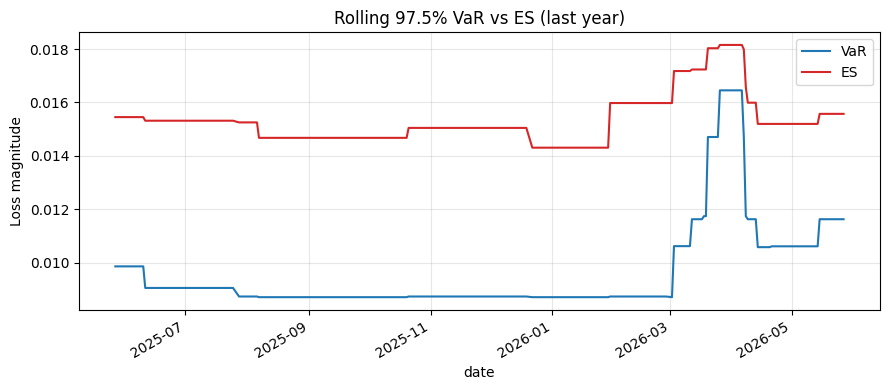

In [6]:
roll = rolling_var_es(port).dropna()
roll.tail(VAR_WINDOW).rename(columns={'var': 'VaR', 'es': 'ES'}).plot(
    title='Rolling 97.5% VaR vs ES (last year)', color=['#1f77b4', '#d62728'])
plt.ylabel('Loss magnitude'); plt.tight_layout(); plt.show()

## 5. Does the model hold up? VaR backtests

Using yesterday's forecast to predict today (no look-ahead), we test the VaR exceedance sequence with **Kupiec POF** (is the breach rate ~2.5%?) and **Christoffersen** (are breaches independent or clustered?). A small p-value rejects the model.

In [7]:
es_pred, var_pred = roll['es'].shift(1), roll['var'].shift(1)
bt = pd.DataFrame({'R': port, 'var': var_pred, 'es': es_pred}).dropna()
breaches = breaches_from(bt['R'].to_numpy(), bt['var'].to_numpy())
kup = kupiec_pof(breaches, ALPHA)
chr_ = christoffersen(breaches, ALPHA)
print(f"Observations : {kup['T']:,}")
print(f"Breaches     : {kup['x']}  (rate {kup['breach_rate']:.3%}, target {ALPHA:.1%})")
print(f"Kupiec POF      : LR={kup['LR_pof']:.2f}  p={kup['p_value']:.4f}")
print(f"Christoffersen  : independence LR={chr_['LR_ind']:.2f} p={chr_['p_value_ind']:.4f}")
print(f"Conditional cov : LR={chr_['LR_cc']:.2f} p={chr_['p_value_cc']:.4f}")

Observations : 4,560
Breaches     : 143  (rate 3.136%, target 2.5%)
Kupiec POF      : LR=7.01  p=0.0081
Christoffersen  : independence LR=19.67 p=0.0000
Conditional cov : LR=26.68 p=0.0000


## 6. Capital: IMA vs the Standardised Approach

Banks compute capital under both the Internal Models Approach (everything above) and the prescribed Standardised Approach (SA). The Basel III **output floor** caps how far the internal model can cut capital: final capital = max(IMA, 72.5% x SA). When the floor binds, the model's lower number does not fully count.

IMA model charge :   8.0% of notional
SA (SBM) charge  :  15.5% of notional
Output floor     :  11.2% (72.5% x SA)
Final capital    :  11.2%  -> binds via SA output floor


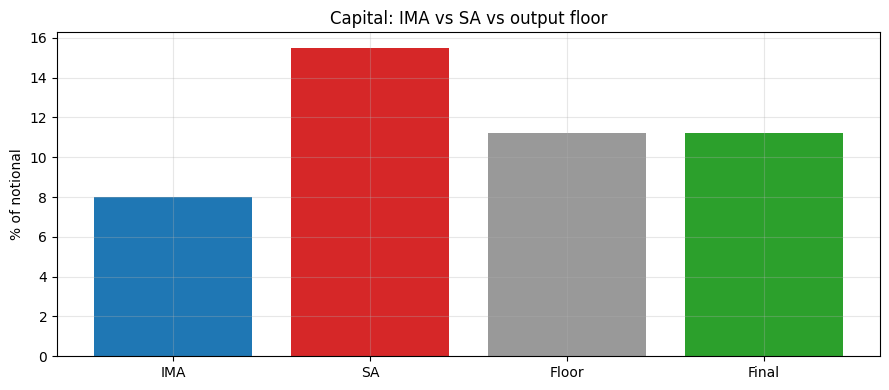

In [8]:
es_now = roll['es'].iloc[-1]
stress_period_es = roll['es'].max()
es_stressed = max(es_now, 0.5 * stress_period_es + 0.5 * es_now)
liq_adj = liquidity_adjusted_es(wide).dropna().iloc[-1]
sa, _ = sbm_delta_charge()
cap = capital_comparison(es_now, es_stressed, liq_adj, sa)
print(f"IMA model charge : {cap['ima']*100:5.1f}% of notional")
print(f"SA (SBM) charge  : {cap['sa']*100:5.1f}% of notional")
print(f"Output floor     : {cap['floor_value']*100:5.1f}% (72.5% x SA)")
print(f"Final capital    : {cap['capital']*100:5.1f}%  -> binds via {cap['binding']}")
labels = ['IMA', 'SA', 'Floor', 'Final']
vals = [cap['ima']*100, cap['sa']*100, cap['floor_value']*100, cap['capital']*100]
plt.bar(labels, vals, color=['#1f77b4', '#d62728', '#999999', '#2ca02c'])
plt.ylabel('% of notional'); plt.title('Capital: IMA vs SA vs output floor')
plt.tight_layout(); plt.show()

## Takeaways

1. **Distributional choice drives the tail** - Normal VaR/ES understates risk versus historical and fat-tailed estimates.
2. **Volatility scaling matters** - Filtered HS reacts to the current regime, addressing the procyclicality of plain HS.
3. **Backtesting is non-negotiable** - a model can look fine yet fail formal coverage/independence tests around volatility shifts.
4. **The SA floors the IMA** - internal models can lower capital, but only to 72.5% of the Standardised Approach charge.

See the [repository](https://github.com/marksguo/frtb-ima-risk-monitor) for the full automated pipeline, dashboard, and weekly ES backtesting.